# Kite gen+cost — East Coast, 2011–2020, depths 50/100/200 m

Gridded `EastCoast_Current_{year}.npz` in (streamed, never loaded whole); one file per
design out, named `kite_{kW}kW_{rfsmin}-{rfsmax}mRFS`, with a depth axis
`Energy_pu (time, n_depths, sites)`.

**Site filter applied first** (before any extraction): land mask, then seafloor depth
50–2000 m and distance-to-shore < 200 km. So every downstream array only holds sites
that survive the filter.

In [1]:
# ================= CONFIG =================
import os, glob, zipfile, time
import numpy as np, pandas as pd
from numpy.lib import format as npformat

BASE = r"C:\Users\rmiller9\Documents\East Coast Model"
os.chdir(BASE)
from GeneralGeoTools_EastCoast import GetDepth, GetDistanceToShore

CUR_DIR  = BASE + r"\Resource Data\Current\EastCoast"
SURF_DIR = BASE + r"\Tech Designs\Current\Power Surfaces"
OUT_DIR  = BASE + r"\Tech Outputs\Current"
TMP_DIR  = CUR_DIR + r"\_kite_tmp"
COASTLINE = BASE + r"\Geospatial Data\CoastLine\ne_10m_coastline.shp"

YEARS = list(range(2011, 2021))
DEVICE_IDS = list(range(10))
OPERATING_DEPTHS = [50, 100, 150, 200]     # water-column depths (must be on current + power grids)

# --- site filter (seafloor bathymetry + distance to shore) ---
SEAFLOOR_MIN, SEAFLOOR_MAX = 50.0, 2000.0   # m
MAX_DIST_KM = 200.0

FCR = 0.10
RES_DEG, RES_KM = 0.08, 8
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(TMP_DIR, exist_ok=True)

def cur_file(y): return os.path.join(CUR_DIR, f"EastCoast_Current_{y}.npz")
for y in YEARS: assert os.path.exists(cur_file(y)), f"missing {cur_file(y)}"
depth_axis = np.load(cur_file(YEARS[0]), allow_pickle=True)["depth"]
DEPTH_IDX = [int(np.where(depth_axis == D)[0][0]) for D in OPERATING_DEPTHS]
print("operating depths", OPERATING_DEPTHS, "-> current indices", DEPTH_IDX)
print(f"site filter: seafloor [{SEAFLOOR_MIN},{SEAFLOOR_MAX}] m, dist < {MAX_DIST_KM} km")

operating depths [50, 100, 150, 200] -> current indices [2, 4, 5, 6]
site filter: seafloor [50.0,2000.0] m, dist < 200.0 km


## Helpers

In [2]:
def _hdr(fp):
    v=npformat.read_magic(fp)
    try: return npformat._read_array_header(fp,v)
    except AttributeError:
        return npformat.read_array_header_1_0(fp) if v==(1,0) else npformat.read_array_header_2_0(fp)

def stream_current(path, depth_idx, keep_cols=None, block=200):
    with zipfile.ZipFile(path) as zf, zf.open("ocean_speed.npy") as f:
        shape,fort,dt=_hdr(f); T,ND,NLA,NLO=shape; per_t=ND*NLA*NLO; it=dt.itemsize
        ncell=NLA*NLO
        for r0 in range(0,T,block):
            r1=min(r0+block,T); nb=r1-r0
            arr=np.frombuffer(f.read(nb*per_t*it),dt).reshape(nb,ND,NLA,NLO)[:,depth_idx,:,:].reshape(nb,len(depth_idx),ncell)
            yield r0, r1, (arr[:,:,keep_cols] if keep_cols is not None else arr)

def n_time(path):
    with zipfile.ZipFile(path) as zf, zf.open("ocean_speed.npy") as f:
        return _hdr(f)[0][0]

def _vfmt(v):
    s=f"{v:g}"; return s if "." in s else s+".0"

def load_design(did):
    dv=pd.read_csv(os.path.join(SURF_DIR,f"kite_{did}Depth_Vector.csv"))["Depth"].values.astype(float)
    vv=pd.read_csv(os.path.join(SURF_DIR,f"kite_{did}Velocity_Vector.csv"))["Velocity"].values.astype(float)
    pm=pd.read_csv(os.path.join(SURF_DIR,f"kite_{did}.csv"),header=None).values.astype(float)
    capex,opex,rated=pd.read_csv(os.path.join(SURF_DIR,f"kite{did}costInp.csv"),header=None).values.flatten()[:3]
    plateau=[vv[np.argmax(pm[i]>=0.99*pm.max())] for i in range(len(dv))]
    lo,hi=min(plateau),max(plateau)
    rfs=_vfmt(lo) if lo==hi else f"{_vfmt(lo)}-{_vfmt(hi)}"
    name=f"kite_{round(float(rated))}kW_{rfs}mRFS"
    rows=[pm[int(np.where(dv==D)[0][0])] for D in OPERATING_DEPTHS]
    return dict(name=name, vv=vv, rows=rows, capex=float(capex), opex=float(opex), rated=float(rated))

## Site filter (run first) — land mask + seafloor depth + distance

In [3]:
D0 = np.load(cur_file(YEARS[0]), allow_pickle=True)
lat, lon = D0["lat"], D0["lon"]; D0.close()
ncell = len(lat)*len(lon)
lon_m, lat_m = np.meshgrid(lon, lat)
LatLong_all = np.column_stack([lat_m.ravel(), lon_m.ravel()]).astype(np.float32)

# 1) land mask: valid ocean cells (non-NaN at >=1 operating depth), from year 1
print("land mask (year 1)...")
valid = np.zeros((len(OPERATING_DEPTHS), ncell), bool)
for r0,r1,a in stream_current(cur_file(YEARS[0]), DEPTH_IDX):
    valid |= np.any(~np.isnan(a), axis=0)
ocean_cols = np.flatnonzero(valid.any(axis=0))
print(f"  {ncell:,} cells -> {ocean_cols.size:,} ocean cells")

# 2) seafloor depth + distance on ocean cells only (computed once, reused for all designs)
ll = LatLong_all[ocean_cols]
print("GetDepth ...");           t0=time.time(); depth_sea=np.abs(np.asarray(GetDepth(BASE, ll),float));            print(f"  {time.time()-t0:.0f}s")
print("GetDistanceToShore ...");  t0=time.time(); dist=np.asarray(GetDistanceToShore(BASE, ll, CoastlineShpPath=COASTLINE),float); print(f"  {time.time()-t0:.0f}s")

site_ok = (depth_sea>=SEAFLOOR_MIN)&(depth_sea<=SEAFLOOR_MAX)&(dist<MAX_DIST_KM)
keep_cols = ocean_cols[site_ok]
ValidSites = valid[:, keep_cols]
LatLong    = LatLong_all[keep_cols]
Depth_keep = depth_sea[site_ok]
Dist_keep  = dist[site_ok]
n_keep = keep_cols.size
print(f"seafloor [{SEAFLOOR_MIN},{SEAFLOOR_MAX}] & dist<{MAX_DIST_KM}: {ocean_cols.size:,} -> {n_keep:,} sites")

land mask (year 1)...
  70,929 cells -> 37,319 ocean cells
GetDepth ...

 Calculating water depth at each point


100%|██████████| 3732/3732 [17:19<00:00,  3.59it/s]


  1057s
GetDistanceToShore ...

 Calculating distance to shore for viable site locations


100%|██████████| 1866/1866 [02:53<00:00, 10.77it/s]

  194s
seafloor [50.0,2000.0] & dist<200.0: 37,319 -> 8,924 sites


## Pass 1 — extract 3 depths for the filtered sites

In [4]:
year_len=[]; datetimes=[]
for y in YEARS:
    tp = os.path.join(TMP_DIR, f"_curr_{y}.npy")
    T = n_time(cur_file(y)); year_len.append(T)
    datetimes.append(np.load(cur_file(y), allow_pickle=True)["datetime"])
    if os.path.exists(tp): print(f"  {y}: temp exists"); continue
    mm = npformat.open_memmap(tp, mode="w+", dtype=np.float16, shape=(T,len(DEPTH_IDX),n_keep))
    t0=time.time()
    for r0,r1,a in stream_current(cur_file(y), DEPTH_IDX, keep_cols):
        mm[r0:r1] = np.where(np.isnan(a), 0.0, a).astype(np.float16)
    mm.flush(); del mm
    print(f"  {y}: {T} steps -> temp ({time.time()-t0:.0f}s)")

TimeList = np.concatenate(datetimes); T_total=int(sum(year_len))
print(f"T_total={T_total:,}, sites={n_keep:,}")

  2011: 2920 steps -> temp (13s)
  2012: 2928 steps -> temp (16s)
  2013: 2920 steps -> temp (15s)
  2014: 2920 steps -> temp (15s)
  2015: 2920 steps -> temp (15s)
  2016: 2928 steps -> temp (16s)
  2017: 2920 steps -> temp (16s)
  2018: 2920 steps -> temp (16s)
  2019: 2920 steps -> temp (15s)
  2020: 2928 steps -> temp (13s)
T_total=29,224, sites=8,924


## Pass 2 — evaluate each design

In [5]:
def evaluate_design(did):
    d = load_design(did)
    out_path = os.path.join(OUT_DIR, f"{d['name']}.npz")
    print("="*64); print(f"design {did} -> {d['name']}")
    if os.path.exists(out_path): print("  exists, skip"); return

    epu_tmp = os.path.join(TMP_DIR, f"_epu_{did}.npy")
    Energy_pu = npformat.open_memmap(epu_tmp, mode="w+", dtype=np.float16,
                                     shape=(T_total, len(OPERATING_DEPTHS), n_keep))
    off=0; t0=time.time()
    for y,yl in zip(YEARS, year_len):
        cur = np.load(os.path.join(TMP_DIR, f"_curr_{y}.npy"))
        for di in range(len(OPERATING_DEPTHS)):
            vv, row = d["vv"], d["rows"][di]
            sp = cur[:,di,:].astype(np.float32)
            P = np.interp(sp, vv, row); P[(sp<vv[0])|(sp>vv[-1])] = 0.0
            Energy_pu[off:off+yl, di, :] = (P/d["rated"]).astype(np.float16)
        off += yl
    print(f"  power {time.time()-t0:.0f}s")

    CF = np.asarray(Energy_pu, np.float32).mean(axis=0)
    annual_cost = FCR*d["capex"] + d["opex"]
    annual_energy_mwh = CF * d["rated"] * 8760 / 1000.0
    with np.errstate(divide="ignore", invalid="ignore"):
        LCOE = np.where(annual_energy_mwh > 0, annual_cost/annual_energy_mwh, np.inf)

    np.savez_compressed(out_path,
        Energy_pu=np.asarray(Energy_pu),
        LatLong=LatLong, Depth=Depth_keep, DistanceShore=Dist_keep.astype(np.float16),
        Depth_m=np.array(OPERATING_DEPTHS),
        AnnualizedCost=np.full(n_keep,(FCR*d["capex"]+d["opex"])/1e6,np.float32),
        RatedPower=np.float64(d["rated"]/1000.0),
        TimeList=TimeList, NumberOfCellsPerSite=np.ones(n_keep),
        ResolutionDegrees=np.float32(RES_DEG), ResolutionKm=np.float32(RES_KM),
        ValidSites=ValidSites, LCOE=LCOE.astype(np.float16),
        CapacityFactor=CF.astype(np.float16), CAPEX=d["capex"], OPEX=d["opex"])
    del Energy_pu; os.remove(epu_tmp)
    finite=np.isfinite(LCOE)&ValidSites
    print(f"  saved {d['name']}.npz  ({n_keep:,} sites x {len(OPERATING_DEPTHS)} depths, "
          f"{os.path.getsize(out_path)/1024**3:.2f} GB) | mean CF {CF[ValidSites].mean():.3f} "
          f"| median LCOE ${np.median(LCOE[finite]):.0f}")

for did in DEVICE_IDS: evaluate_design(did)
for y in YEARS:
    tp=os.path.join(TMP_DIR,f"_curr_{y}.npy")
    if os.path.exists(tp): os.remove(tp)
print("Done.")

design 0 -> kite_54kW_0.5-0.75mRFS
  power 32s


C:\Users\rmiller9\AppData\Local\Temp\5\ipykernel_41956\2626029820.py:35: RuntimeWarning: overflow encountered in cast
  ValidSites=ValidSites, LCOE=LCOE.astype(np.float16),


  saved kite_54kW_0.5-0.75mRFS.npz  (8,924 sites x 4 depths, 0.10 GB) | mean CF 0.181 | median LCOE $1224
design 1 -> kite_147kW_0.75-1.0mRFS
  power 31s


C:\Users\rmiller9\AppData\Local\Temp\5\ipykernel_41956\2626029820.py:35: RuntimeWarning: overflow encountered in cast
  ValidSites=ValidSites, LCOE=LCOE.astype(np.float16),


  saved kite_147kW_0.75-1.0mRFS.npz  (8,924 sites x 4 depths, 0.17 GB) | mean CF 0.155 | median LCOE $1534
design 2 -> kite_313kW_1.0-1.25mRFS
  power 32s


...

  saved kite_1988kW_2.0-2.5mRFS.npz  (8,924 sites x 4 depths, 0.28 GB) | mean CF 0.023 | median LCOE $16032
design 8 -> kite_1872kW_1.5-1.75mRFS
  power 35s


C:\Users\rmiller9\AppData\Local\Temp\5\ipykernel_41956\2626029820.py:35: RuntimeWarning: overflow encountered in cast
  ValidSites=ValidSites, LCOE=LCOE.astype(np.float16),


  saved kite_1872kW_1.5-1.75mRFS.npz  (8,924 sites x 4 depths, 0.27 GB) | mean CF 0.032 | median LCOE $10073
design 9 -> kite_1814kW_0.5-2.75mRFS
  power 43s


C:\Users\rmiller9\AppData\Local\Temp\5\ipykernel_41956\2626029820.py:35: RuntimeWarning: overflow encountered in cast
  ValidSites=ValidSites, LCOE=LCOE.astype(np.float16),


  saved kite_1814kW_0.5-2.75mRFS.npz  (8,924 sites x 4 depths, 0.28 GB) | mean CF 0.013 | median LCOE $28980
Done.


In [6]:
import numpy as np, glob, os
for p in sorted(glob.glob(r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Current\kite_*.npz")):
    D=np.load(p,allow_pickle=True)
    print(f"{os.path.basename(p):32s} {os.path.getsize(p)/1024**3:5.2f} GB  Energy_pu{D['Energy_pu'].shape}  meanCF {np.asarray(D['Energy_pu'],np.float32).mean():.3f}")
    D.close()

kite_1432kW_1.5-2.0mRFS.npz       0.27 GB  Energy_pu(29224, 4, 8924)  meanCF 0.032
kite_147kW_0.75-1.0mRFS.npz       0.17 GB  Energy_pu(29224, 4, 8924)  meanCF 0.109
kite_1814kW_0.5-2.75mRFS.npz      0.28 GB  Energy_pu(29224, 4, 8924)  meanCF 0.009
kite_1872kW_1.5-1.75mRFS.npz      0.27 GB  Energy_pu(29224, 4, 8924)  meanCF 0.023
kite_1988kW_2.0-2.5mRFS.npz       0.28 GB  Energy_pu(29224, 4, 8924)  meanCF 0.016
kite_2041kW_1.75-2.25mRFS.npz     0.27 GB  Energy_pu(29224, 4, 8924)  meanCF 0.023
kite_313kW_1.0-1.25mRFS.npz       0.23 GB  Energy_pu(29224, 4, 8924)  meanCF 0.086
kite_54kW_0.5-0.75mRFS.npz        0.10 GB  Energy_pu(29224, 4, 8924)  meanCF 0.128
kite_571kW_1.25-1.5mRFS.npz       0.25 GB  Energy_pu(29224, 4, 8924)  meanCF 0.063
kite_932kW_1.5-1.75mRFS.npz       0.27 GB  Energy_pu(29224, 4, 8924)  meanCF 0.045


C:\Users\rmiller9\AppData\Local\Temp\5\ipykernel_41956\1575862597.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.05,1,1]); plt.show()


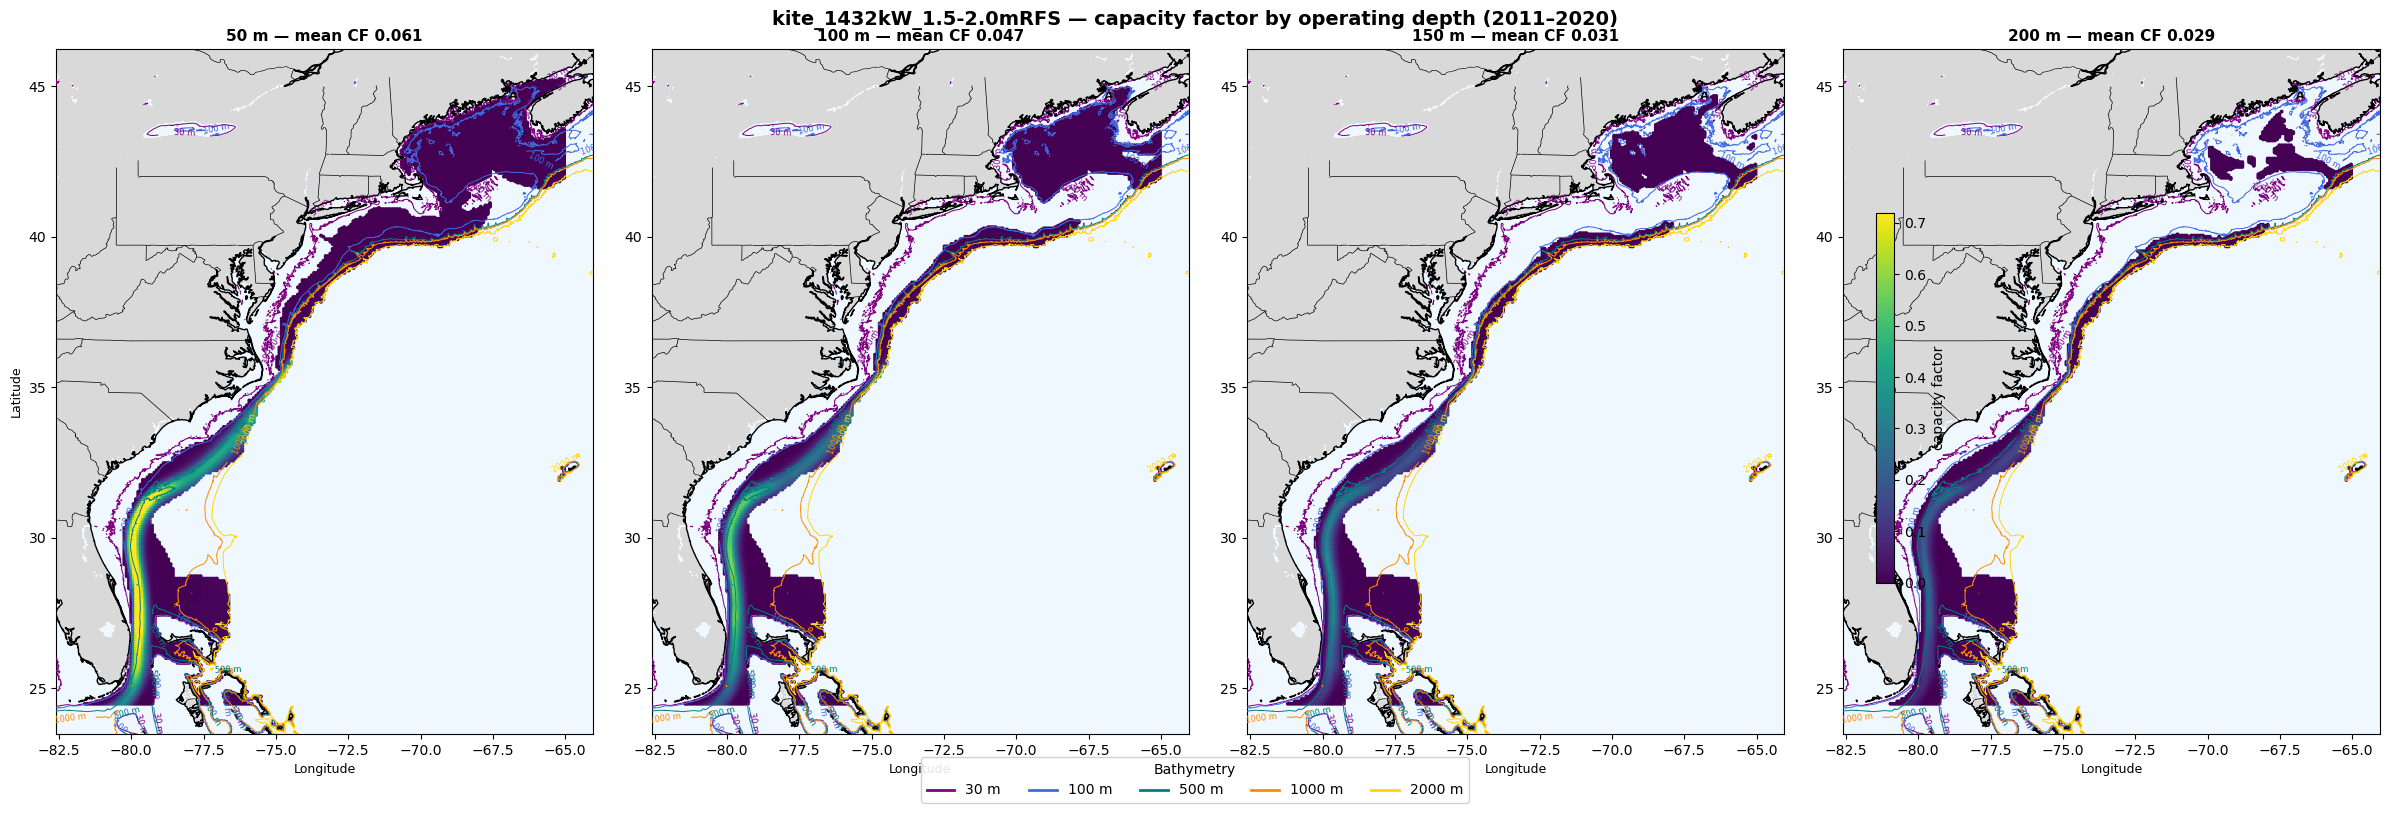

KeyboardInterrupt: 

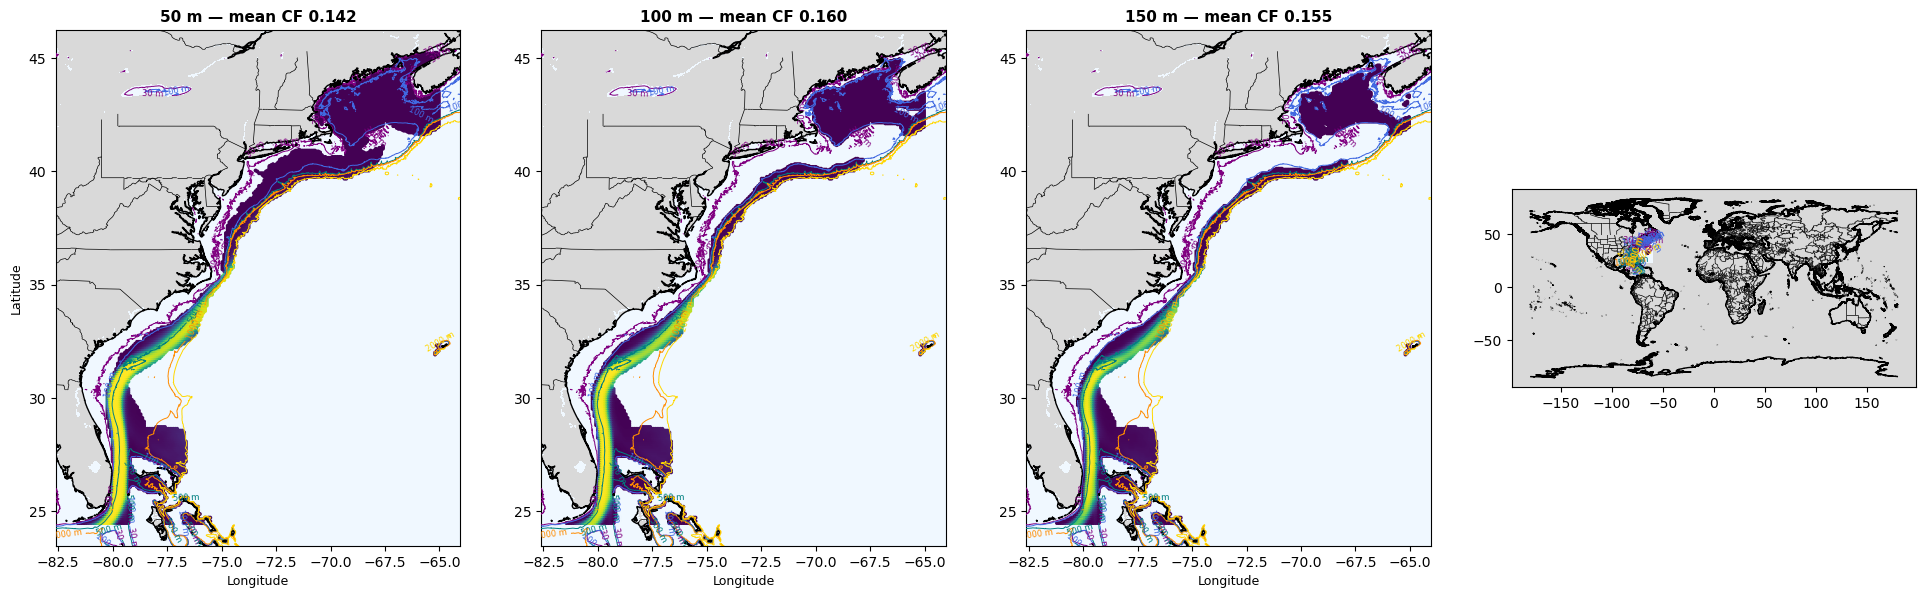

In [7]:
import numpy as np, glob, os
import geopandas as gpd, xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUT_DIR = r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Current"
DEPTH_NC    = r"C:\Users\rmiller9\Documents\East Coast Model\Depths_EastCoast_Offshore.nc"
COAST_SHP   = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"
DEPTH_LEVELS=[30,100,500,1000,2000]
DEPTH_COLORS={30:"purple",100:"royalblue",500:"teal",1000:"darkorange",2000:"gold"}

ds=xr.open_dataset(DEPTH_NC); lat_d=ds["lat"].values[::2]; lon_d=ds["lon"].values[::2]
depth=ds["depth"].values[::2,::2]; LonGrid,LatGrid=np.meshgrid(lon_d,lat_d); ds.close()
coast=gpd.read_file(COAST_SHP); borders=gpd.read_file(BORDERS_SHP)
coast=coast.set_crs(4326) if coast.crs is None else coast.to_crs(4326)
borders=borders.set_crs(4326) if borders.crs is None else borders.to_crs(4326)

for p in sorted(glob.glob(os.path.join(OUT_DIR,"kite_*.npz"))):
    D=np.load(p,allow_pickle=True)
    ll=D["LatLong"]; CF=np.asarray(D["CapacityFactor"],np.float32); vs=D["ValidSites"]
    depths=D["Depth_m"]; name=os.path.basename(p)[:-4]; D.close()

    XLIM=(ll[:,1].min()-1,ll[:,1].max()+1); YLIM=(ll[:,0].min()-1,ll[:,0].max()+1)
    valid_cf=CF[vs]; vmax=np.percentile(valid_cf[valid_cf>0],99) if (valid_cf>0).any() else 1
    fig,axes=plt.subplots(1,len(depths),figsize=(6*len(depths),8))
    if len(depths)==1: axes=[axes]
    for ax,di in zip(axes,range(len(depths))):
        m=vs[di]
        ax.set_facecolor("#d9d9d9")
        ax.contourf(LonGrid,LatGrid,depth,levels=[0,depth.max()],colors=["aliceblue"],zorder=0)
        sc=ax.scatter(ll[m,1],ll[m,0],c=CF[di,m],s=8,cmap="viridis",vmin=0,vmax=vmax,edgecolors="none",zorder=2)
        for lvl in DEPTH_LEVELS:
            cs=ax.contour(LonGrid,LatGrid,depth,levels=[lvl],colors=[DEPTH_COLORS[lvl]],linewidths=0.7,zorder=3)
            ax.clabel(cs,inline=True,fontsize=6,fmt={lvl:f"{lvl} m"})
        coast.plot(ax=ax,linewidth=1.0,color="black",zorder=4)
        borders.plot(ax=ax,linewidth=0.5,color="black",zorder=4)
        ax.set_xlim(XLIM); ax.set_ylim(YLIM); ax.set_xlabel("Longitude",fontsize=9)
        if di==0: ax.set_ylabel("Latitude",fontsize=9)
        ax.set_title(f"{int(depths[di])} m — mean CF {CF[di,m].mean():.3f}",fontsize=11,fontweight="bold")
    fig.colorbar(sc,ax=axes,shrink=0.6,label="capacity factor")
    depth_h=[Line2D([0],[0],color=DEPTH_COLORS[l],lw=2,label=f"{l} m") for l in DEPTH_LEVELS]
    fig.legend(handles=depth_h,loc="lower center",ncol=len(DEPTH_LEVELS),frameon=True,
               framealpha=0.9,facecolor="white",title="Bathymetry",bbox_to_anchor=(0.5,-0.02))
    fig.suptitle(f"{name} — capacity factor by operating depth (2011–2020)",fontsize=14,fontweight="bold")
    plt.tight_layout(rect=[0,0.05,1,1]); plt.show()

10 designs, depths [50, 100, 150, 200]


C:\Users\rmiller9\AppData\Local\Temp\5\ipykernel_41956\3060212039.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.05,1,1]); plt.show()


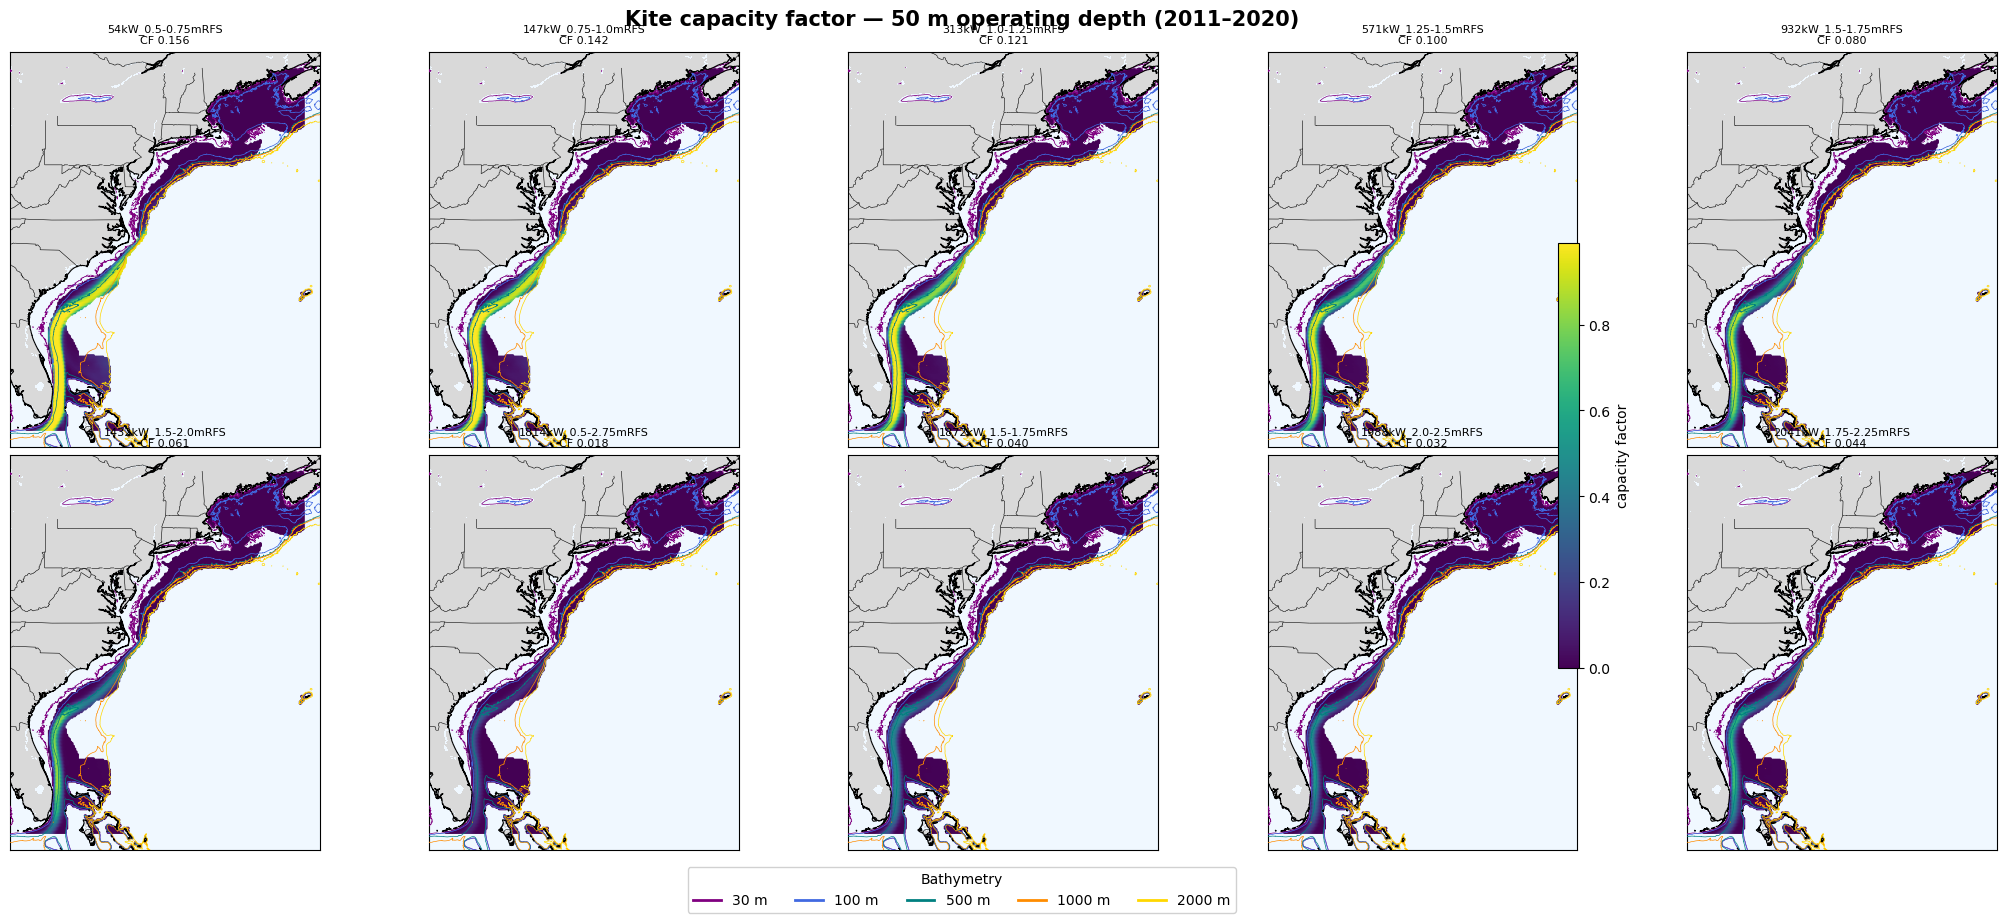

C:\Users\rmiller9\AppData\Local\Temp\5\ipykernel_41956\3060212039.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.05,1,1]); plt.show()


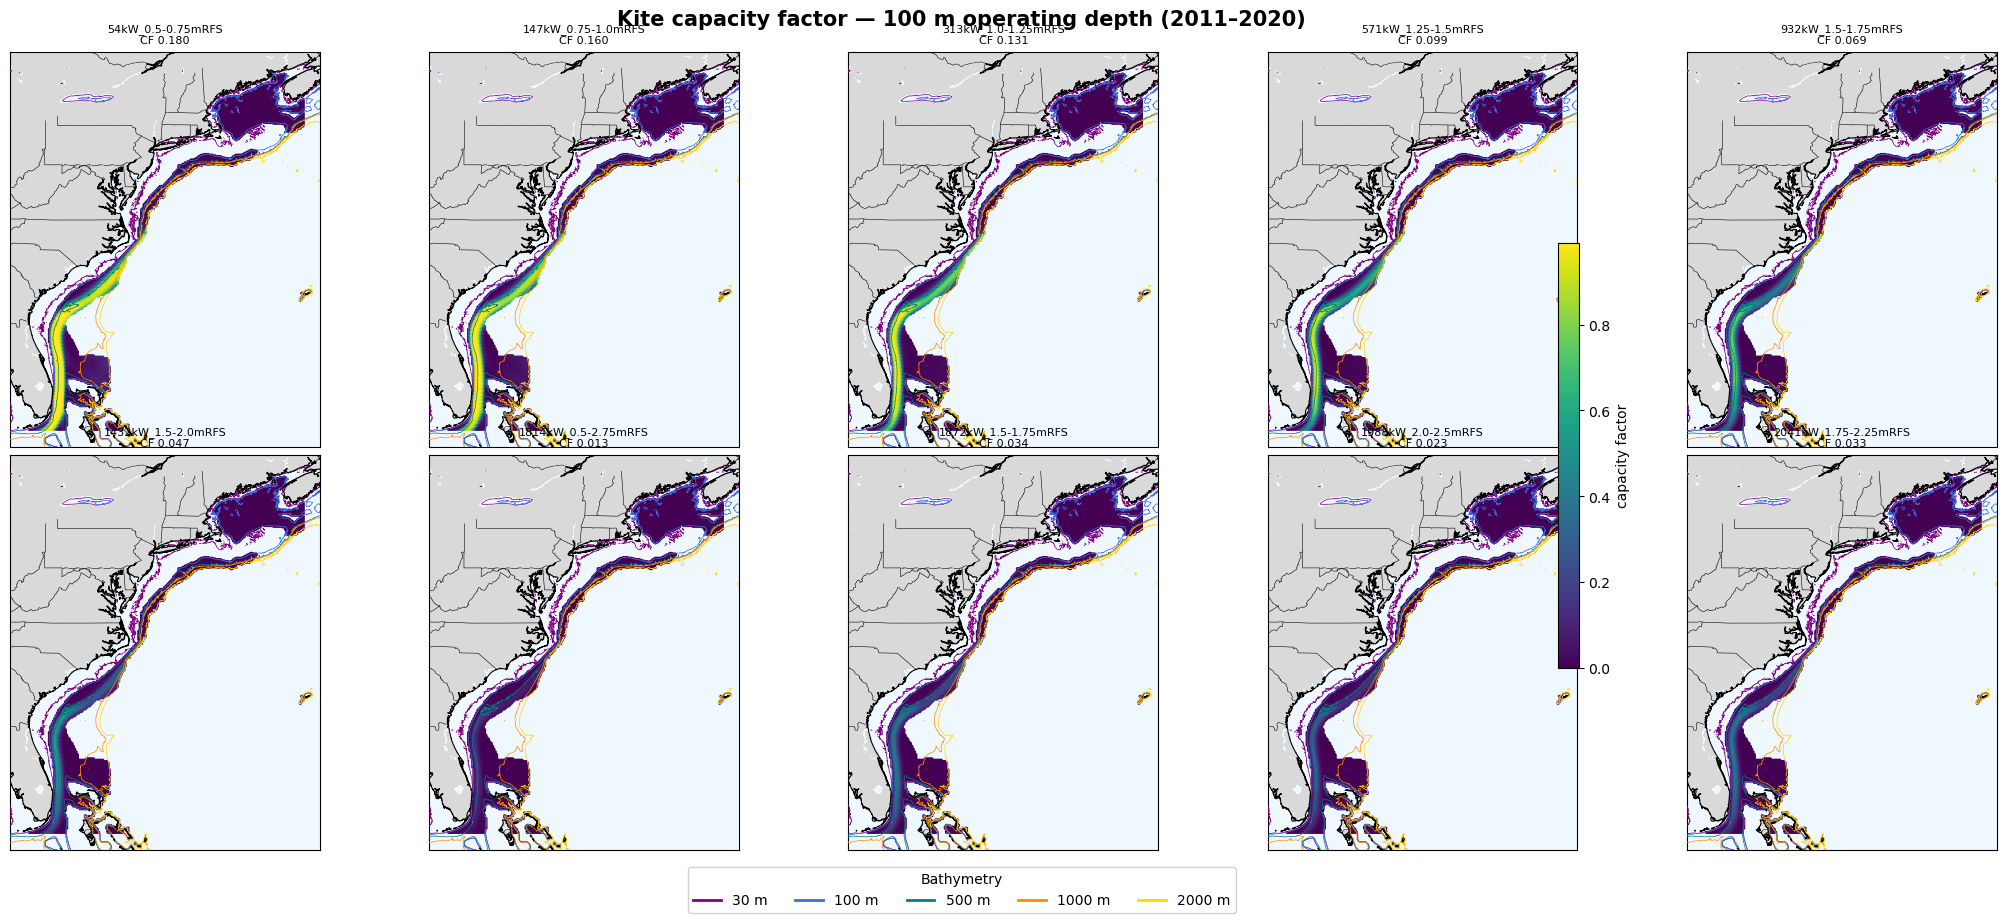

C:\Users\rmiller9\AppData\Local\Temp\5\ipykernel_41956\3060212039.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.05,1,1]); plt.show()


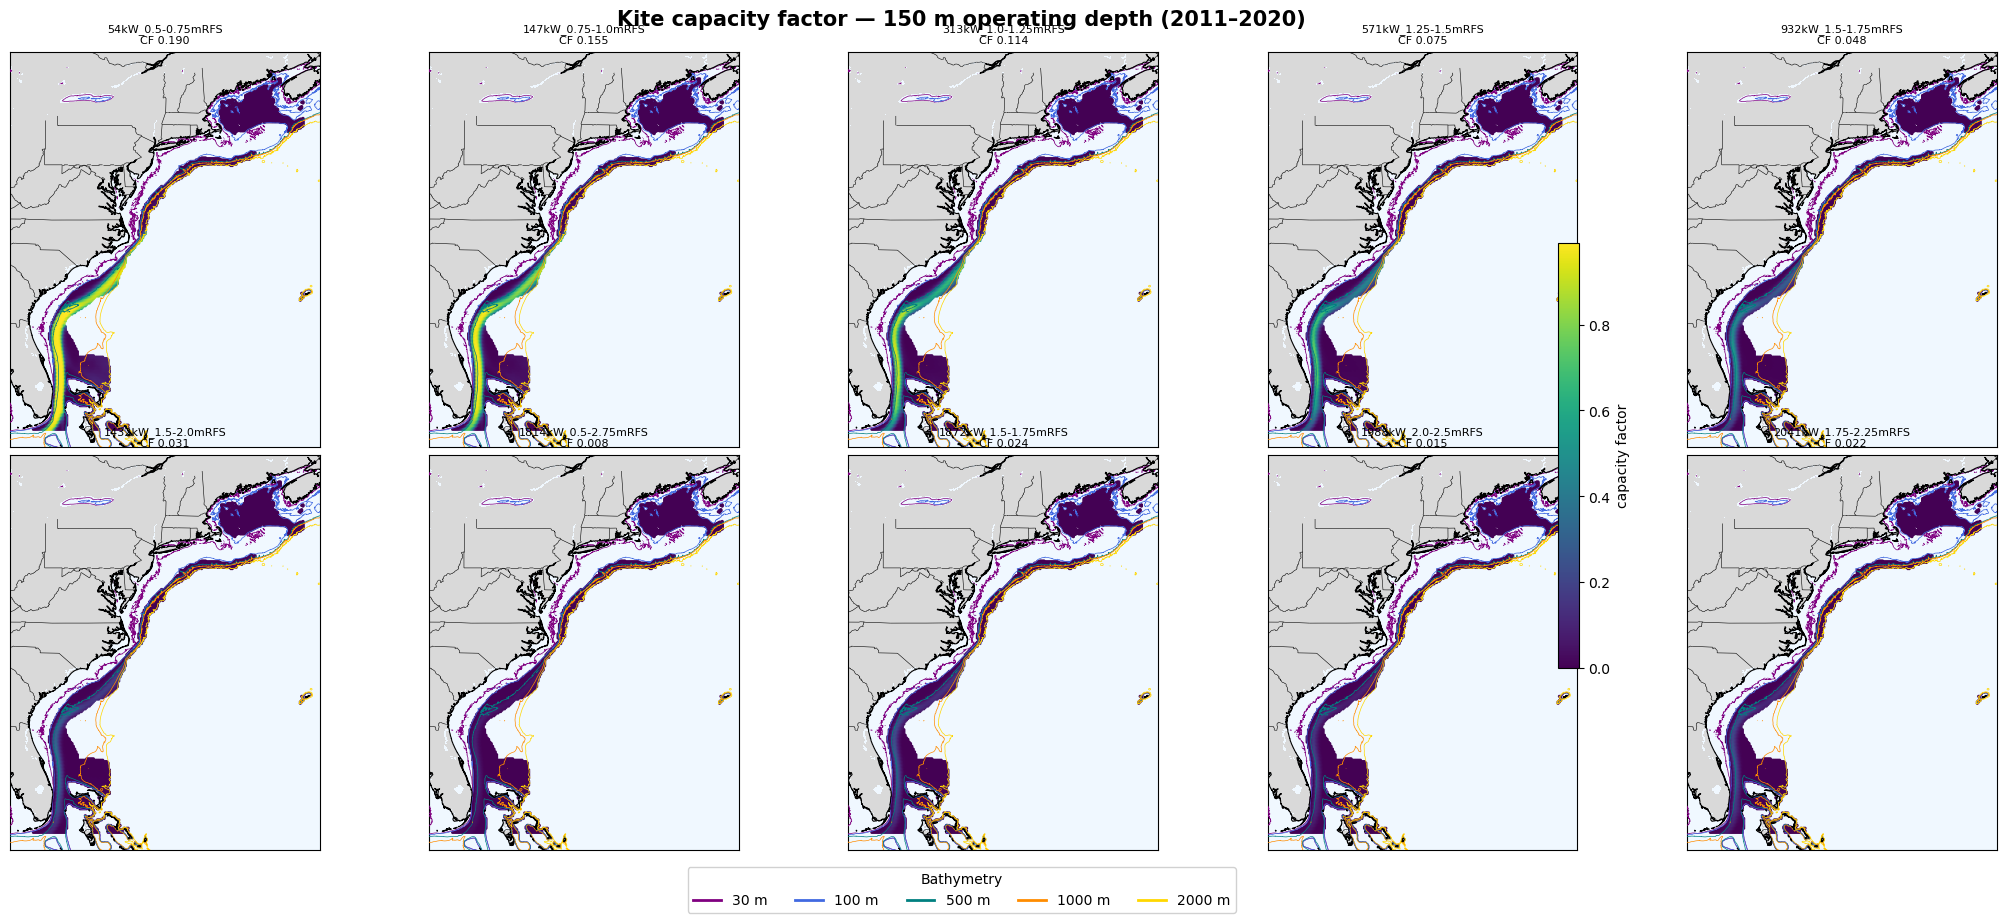

C:\Users\rmiller9\AppData\Local\Temp\5\ipykernel_41956\3060212039.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.05,1,1]); plt.show()


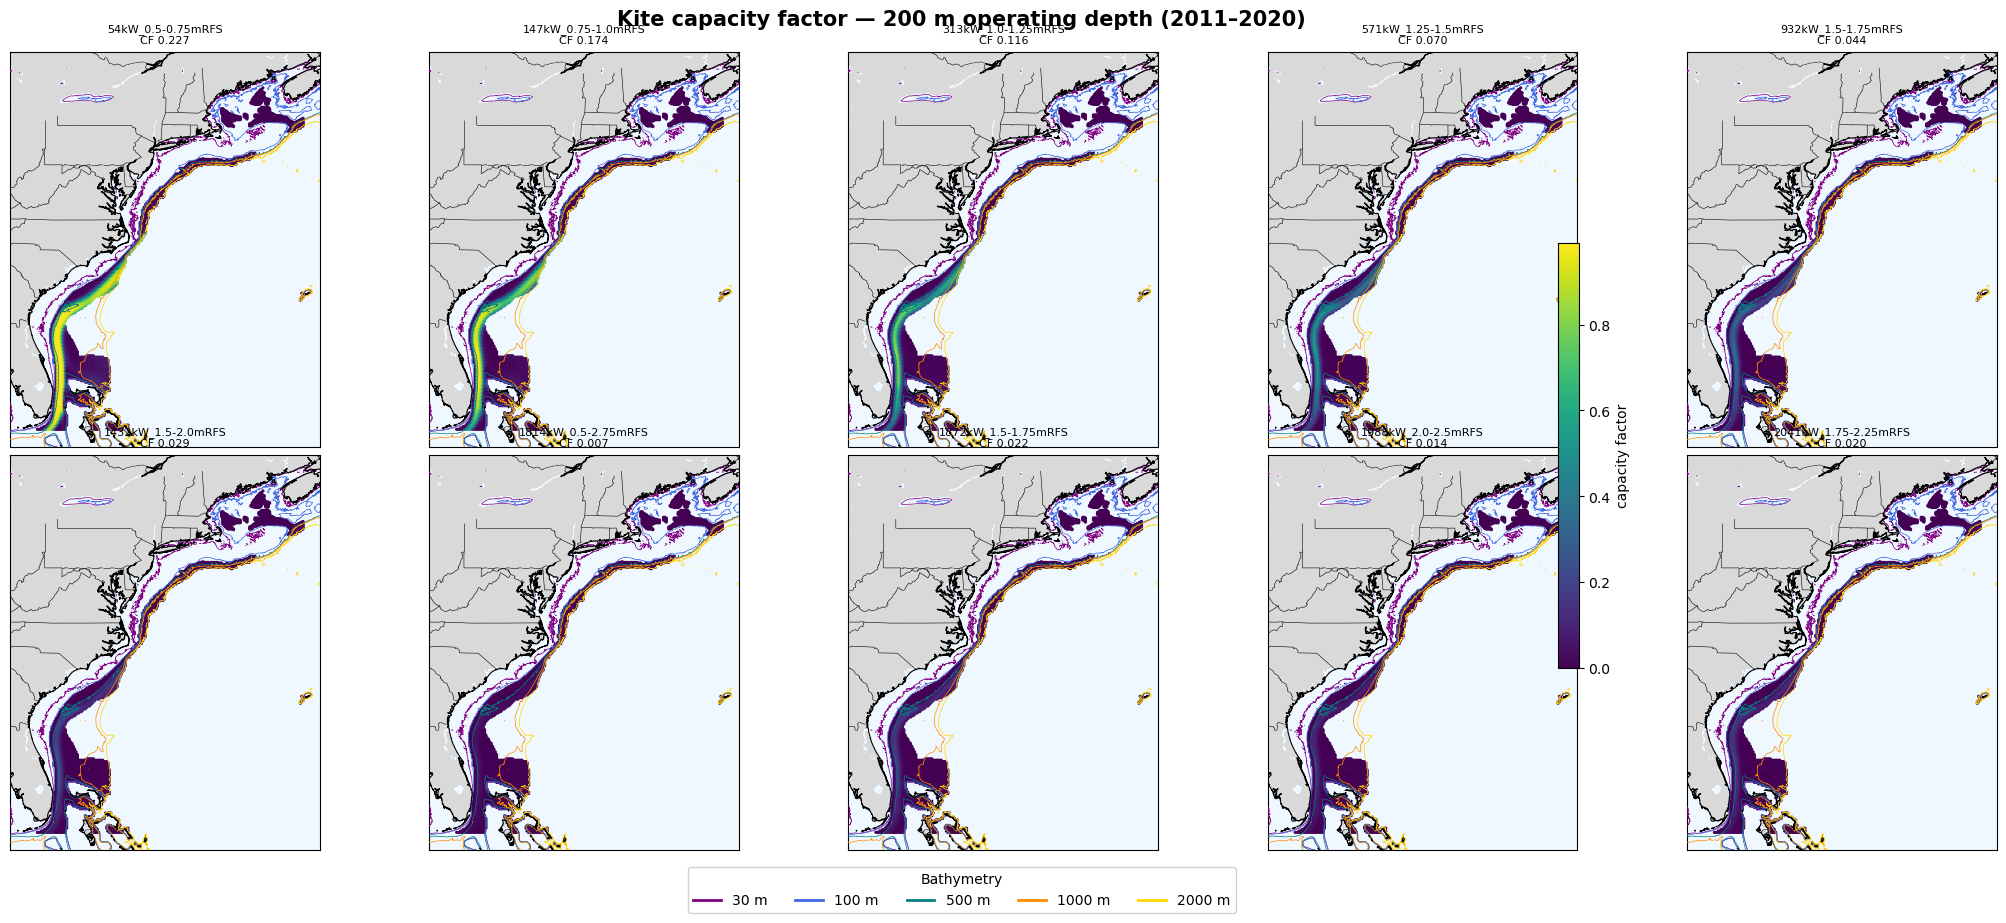

In [8]:
import numpy as np, glob, os, re
import geopandas as gpd, xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUT_DIR = r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Current"
DEPTH_NC    = r"C:\Users\rmiller9\Documents\East Coast Model\Depths_EastCoast_Offshore.nc"
COAST_SHP   = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"
DEPTH_LEVELS=[30,100,500,1000,2000]
DEPTH_COLORS={30:"purple",100:"royalblue",500:"teal",1000:"darkorange",2000:"gold"}

# geo overlays (once)
ds=xr.open_dataset(DEPTH_NC); lat_d=ds["lat"].values[::2]; lon_d=ds["lon"].values[::2]
depth=ds["depth"].values[::2,::2]; LonGrid,LatGrid=np.meshgrid(lon_d,lat_d); ds.close()
coast=gpd.read_file(COAST_SHP); borders=gpd.read_file(BORDERS_SHP)
coast=coast.set_crs(4326) if coast.crs is None else coast.to_crs(4326)
borders=borders.set_crs(4326) if borders.crs is None else borders.to_crs(4326)

# load every kite design (CF/coords/valid are small — no streaming)
files=sorted(glob.glob(os.path.join(OUT_DIR,"kite_*.npz")),
             key=lambda p:int(re.search(r"kite_(\d+)kW",p).group(1)))  # order by rated kW
designs=[]
for p in files:
    D=np.load(p,allow_pickle=True)
    designs.append(dict(name=os.path.basename(p)[:-4], ll=D["LatLong"],
                        cf=np.asarray(D["CapacityFactor"],np.float32),
                        vs=D["ValidSites"], depths=D["Depth_m"])); D.close()
n_dep=len(designs[0]["depths"]); depths=designs[0]["depths"]
print(f"{len(designs)} designs, depths {list(depths)}")

# shared color scale across all panels
allcf=np.concatenate([d["cf"][d["vs"]] for d in designs])
vmax=np.percentile(allcf[allcf>0],99)
ll0=designs[0]["ll"]; XLIM=(ll0[:,1].min()-1,ll0[:,1].max()+1); YLIM=(ll0[:,0].min()-1,ll0[:,0].max()+1)

nrow,ncol=2,5   # 10 designs
for di in range(n_dep):
    fig,axes=plt.subplots(nrow,ncol,figsize=(4.2*ncol,4.6*nrow))
    for ax,d in zip(axes.flatten(),designs):
        m=d["vs"][di]
        ax.set_facecolor("#d9d9d9")
        ax.contourf(LonGrid,LatGrid,depth,levels=[0,depth.max()],colors=["aliceblue"],zorder=0)
        sc=ax.scatter(d["ll"][m,1],d["ll"][m,0],c=d["cf"][di,m],s=5,cmap="viridis",
                      vmin=0,vmax=vmax,edgecolors="none",zorder=2)
        for lvl in DEPTH_LEVELS:
            ax.contour(LonGrid,LatGrid,depth,levels=[lvl],colors=[DEPTH_COLORS[lvl]],linewidths=0.5,zorder=3)
        coast.plot(ax=ax,linewidth=0.8,color="black",zorder=4)
        borders.plot(ax=ax,linewidth=0.4,color="black",zorder=4)
        ax.set_xlim(XLIM); ax.set_ylim(YLIM)
        ax.set_xticks([]); ax.set_yticks([])
        mcf=d["cf"][di,m].mean() if m.any() else 0
        ax.set_title(f"{d['name'].replace('kite_','')}\nCF {mcf:.3f}",fontsize=8)
    for ax in axes.flatten()[len(designs):]: ax.axis("off")
    cbar=fig.colorbar(sc,ax=axes,shrink=0.6,label="capacity factor")
    depth_h=[Line2D([0],[0],color=DEPTH_COLORS[l],lw=2,label=f"{l} m") for l in DEPTH_LEVELS]
    fig.legend(handles=depth_h,loc="lower center",ncol=len(DEPTH_LEVELS),frameon=True,
               framealpha=0.9,facecolor="white",title="Bathymetry",bbox_to_anchor=(0.5,-0.01))
    fig.suptitle(f"Kite capacity factor — {int(depths[di])} m operating depth (2011–2020)",
                 fontsize=15,fontweight="bold")
    plt.tight_layout(rect=[0,0.05,1,1]); plt.show()

In [9]:
import numpy as np
D=np.load(r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Current\kite_54kW_0.5-0.75mRFS.npz",allow_pickle=True)
sea=D["Depth"]; vs=D["ValidSites"]; deps=D["Depth_m"]
for i,dep in enumerate(deps):
    print(f"{int(dep):3d} m op: {vs[i].sum():6d} valid | shallowest valid seafloor = {sea[vs[i]].min():.0f} m")
D.close()

 50 m op:   8924 valid | shallowest valid seafloor = 50 m
100 m op:   6736 valid | shallowest valid seafloor = 50 m
150 m op:   5492 valid | shallowest valid seafloor = 50 m
200 m op:   4099 valid | shallowest valid seafloor = 50 m


cells with 50 m data: 37,319 of 70,929


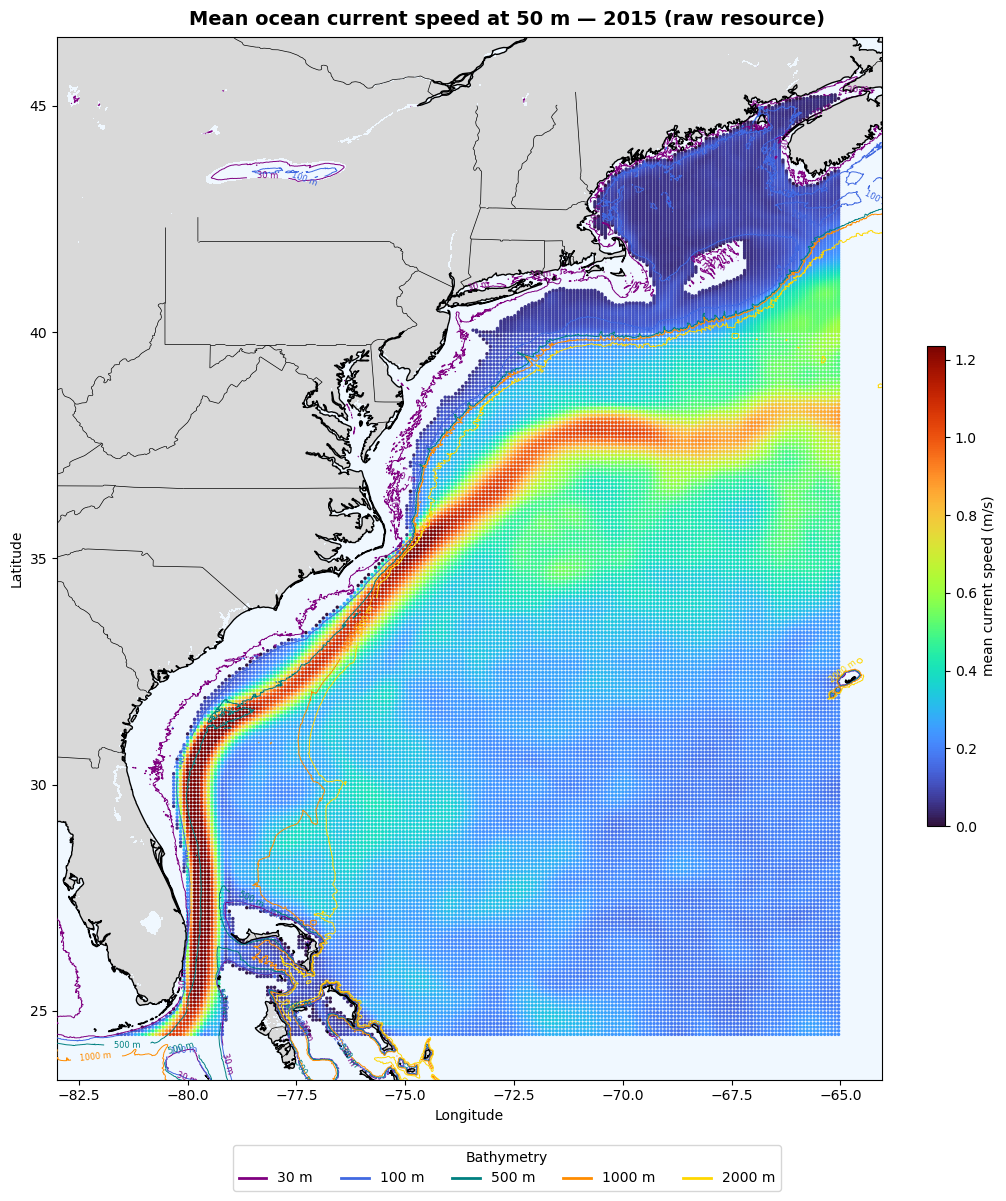

In [10]:
import numpy as np, zipfile
import geopandas as gpd, xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from numpy.lib import format as npformat

BASE = r"C:\Users\rmiller9\Documents\East Coast Model"
CUR = BASE + r"\Resource Data\Current\EastCoast\EastCoast_Current_2015.npz"
DEPTH_NC    = BASE + r"\Depths_EastCoast_Offshore.nc"
COAST_SHP   = BASE + r"\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = BASE + r"\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"
OP_DEPTH = 50
DEPTH_LEVELS=[30,100,500,1000,2000]; DEPTH_COLORS={30:"purple",100:"royalblue",500:"teal",1000:"darkorange",2000:"gold"}

def _hdr(fp):
    v=npformat.read_magic(fp)
    try: return npformat._read_array_header(fp,v)
    except AttributeError:
        return npformat.read_array_header_1_0(fp) if v==(1,0) else npformat.read_array_header_2_0(fp)

# grid axes + depth index
G=np.load(CUR,allow_pickle=True); lat=G["lat"]; lon=G["lon"]; dvec=G["depth"]; G.close()
di=int(np.where(dvec==OP_DEPTH)[0][0]); NLA,NLO=len(lat),len(lon)

# stream ocean_speed at the 50 m layer only, time-mean (nanmean so land stays NaN)
with zipfile.ZipFile(CUR) as zf, zf.open("ocean_speed.npy") as f:
    shape,fort,dt=_hdr(f); T,ND,_,_=shape; per_t=ND*NLA*NLO; it=dt.itemsize
    ssum=np.zeros(NLA*NLO); scnt=np.zeros(NLA*NLO)
    for r0 in range(0,T,200):
        r1=min(r0+200,T); nb=r1-r0
        a=np.frombuffer(f.read(nb*per_t*it),dt).reshape(nb,ND,NLA,NLO)[:,di,:,:].reshape(nb,NLA*NLO)
        good=~np.isnan(a); ssum+=np.where(good,a,0).sum(0); scnt+=good.sum(0)
mean_speed=np.where(scnt>0, ssum/np.maximum(scnt,1), np.nan).reshape(NLA,NLO)
print(f"cells with 50 m data: {(scnt>0).sum():,} of {NLA*NLO:,}")

# overlays
ds=xr.open_dataset(DEPTH_NC); lat_d=ds["lat"].values[::2]; lon_d=ds["lon"].values[::2]
depth=ds["depth"].values[::2,::2]; LonG,LatG=np.meshgrid(lon_d,lat_d); ds.close()
coast=gpd.read_file(COAST_SHP); borders=gpd.read_file(BORDERS_SHP)
coast=coast.set_crs(4326) if coast.crs is None else coast.to_crs(4326)
borders=borders.set_crs(4326) if borders.crs is None else borders.to_crs(4326)
LonMesh,LatMesh=np.meshgrid(lon,lat)

fig,ax=plt.subplots(figsize=(10,12))
ax.set_facecolor("#d9d9d9")
ax.contourf(LonG,LatG,depth,levels=[0,depth.max()],colors=["aliceblue"],zorder=0)
sc=ax.scatter(LonMesh.ravel(),LatMesh.ravel(),c=mean_speed.ravel(),s=6,cmap="turbo",
              vmin=0,vmax=np.nanpercentile(mean_speed,99),edgecolors="none",zorder=2)
for lvl in DEPTH_LEVELS:
    cs=ax.contour(LonG,LatG,depth,levels=[lvl],colors=[DEPTH_COLORS[lvl]],linewidths=0.7,zorder=3)
    ax.clabel(cs,inline=True,fontsize=6,fmt={lvl:f"{lvl} m"})
coast.plot(ax=ax,linewidth=1.0,color="black",zorder=4); borders.plot(ax=ax,linewidth=0.5,color="black",zorder=4)
ax.set_xlim(lon.min()-1,lon.max()+1); ax.set_ylim(lat.min()-1,lat.max()+1)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(rect=[0,0.04,0.9,0.97])
cax=fig.add_axes([0.92,0.30,0.018,0.40]); fig.colorbar(sc,cax=cax,label="mean current speed (m/s)")
fig.legend(handles=[Line2D([0],[0],color=DEPTH_COLORS[l],lw=2,label=f"{l} m") for l in DEPTH_LEVELS],
           loc="lower center",ncol=5,frameon=True,facecolor="white",title="Bathymetry",bbox_to_anchor=(0.5,-0.01))
fig.suptitle("Mean ocean current speed at 50 m — 2015 (raw resource)",fontsize=14,fontweight="bold")
plt.show()

In [1]:
import os, glob
FOLDERS = [
    (r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Current", "kite_"),
    (r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Coaxial", "coax_"),
]
for folder, prefix in FOLDERS:
    for p in glob.glob(os.path.join(folder, prefix+"*.npz")):
        if p.endswith("_2011_2020.npz"): continue
        new = p[:-4] + "_2011_2020.npz"
        os.rename(p, new); print("renamed", os.path.basename(new))

renamed kite_1432kW_1.5-2.0mRFS_2011_2020.npz
renamed kite_147kW_0.75-1.0mRFS_2011_2020.npz
renamed kite_1814kW_0.5-2.75mRFS_2011_2020.npz
renamed kite_1872kW_1.5-1.75mRFS_2011_2020.npz
renamed kite_1988kW_2.0-2.5mRFS_2011_2020.npz
renamed kite_2041kW_1.75-2.25mRFS_2011_2020.npz
renamed kite_313kW_1.0-1.25mRFS_2011_2020.npz
renamed kite_54kW_0.5-0.75mRFS_2011_2020.npz
renamed kite_571kW_1.25-1.5mRFS_2011_2020.npz
renamed kite_932kW_1.5-1.75mRFS_2011_2020.npz
renamed coax_1000kW_1.5mRFS_2011_2020.npz
renamed coax_1750kW_1.75mRFS_2011_2020.npz
renamed coax_2000kW_1.75mRFS_2011_2020.npz
renamed coax_600kW_1.0mRFS_2011_2020.npz
